# Practice 3: Customer Clustering - Bước 6.1: KMeans & KMedoids Clustering

---

## 1. Import các thư viện và tải dữ liệu đặc trưng đầy đủ

Chúng ta tải dữ liệu đã tiền xử lý từ `../data/processed_features/`.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
import os

# Load dữ liệu
X_train = pd.read_csv('../data/processed_features/X_train.csv').values
print(f'Kích thước dữ liệu huấn luyện: {X_train.shape}')

Kích thước dữ liệu huấn luyện: (7422, 26)


## 2. Hàm tính điểm Silhouette Score và Giảm chiều PCA từ Scratch

Để đánh giá chất lượng phân cụm và vẽ ranh giới cụm trong không gian 2D.

In [40]:
def custom_silhouette_score(X, labels):
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1]
    n_clusters = len(unique_labels)
    
    if n_clusters < 2:
        return 0.0
        
    # Tính khoảng cách Euclidean
    from scipy.spatial.distance import pdist, squareform
    dists = squareform(pdist(X))
    
    s = np.zeros(n_samples)
    for i in range(n_samples):
        label_i = labels[i]
        if label_i == -1:
            continue
            
        # Tính a_i
        same_cluster = labels == label_i
        same_cluster[i] = False
        if np.sum(same_cluster) > 0:
            a_i = np.mean(dists[i, same_cluster])
        else:
            a_i = 0.0
            
        # Tính b_i
        b_i = np.inf
        for label_j in unique_labels:
            if label_j == label_i:
                continue
            other_cluster = labels == label_j
            mean_dist = np.mean(dists[i, other_cluster])
            if mean_dist < b_i:
                b_i = mean_dist
                
        if max(a_i, b_i) > 0:
            s[i] = (b_i - a_i) / max(a_i, b_i)
        else:
            s[i] = 0.0
            
    valid_points = labels != -1
    return np.mean(s[valid_points])

class CustomPCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        
    def fit(self, X):
        X_arr = np.array(X, dtype=float)
        self.mean_ = np.mean(X_arr, axis=0)
        X_centered = X_arr - self.mean_
        cov_matrix = np.cov(X_centered, rowvar=False, ddof=0)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components_ = eigenvectors[:, sorted_indices][:, :self.n_components]
        return self
        
    def transform(self, X):
        X_arr = np.array(X, dtype=float)
        return np.dot(X_arr - self.mean_, self.components_)
        
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

pca_2d = CustomPCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)

## 3. Lập trình K-Means từ Scratch

In [41]:
class KMeansScratch:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.inertia_ = None
        
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        
        random_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_idx].copy()
        
        for it in range(self.max_iter):
            distances = np.zeros((n_samples, self.n_clusters))
            for k in range(self.n_clusters):
                distances[:, k] = np.sum((X - self.centroids[k])**2, axis=1)
            
            labels = np.argmin(distances, axis=1)
            new_centroids = np.zeros((self.n_clusters, n_features))
            
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                new_centroids[k] = np.mean(cluster_points, axis=0) if len(cluster_points) > 0 else self.centroids[k]
            
            diff = np.sum((new_centroids - self.centroids)**2)
            self.centroids = new_centroids
            if diff < self.tol:
                break
                
        self.inertia_ = np.sum(np.min(distances, axis=1))
        return self
        
    def predict(self, X):
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, self.n_clusters))
        for k in range(self.n_clusters):
            distances[:, k] = np.sum((X - self.centroids[k])**2, axis=1)
        return np.argmin(distances, axis=1)

## 4. Tìm số cụm K tối ưu cho K-Means

K = 2 | Inertia = 18610.32 | Silhouette Score = 0.1998
K = 3 | Inertia = 16640.13 | Silhouette Score = 0.1526
K = 4 | Inertia = 14838.51 | Silhouette Score = 0.1746
K = 5 | Inertia = 13860.68 | Silhouette Score = 0.1692
K = 6 | Inertia = 12514.28 | Silhouette Score = 0.2057


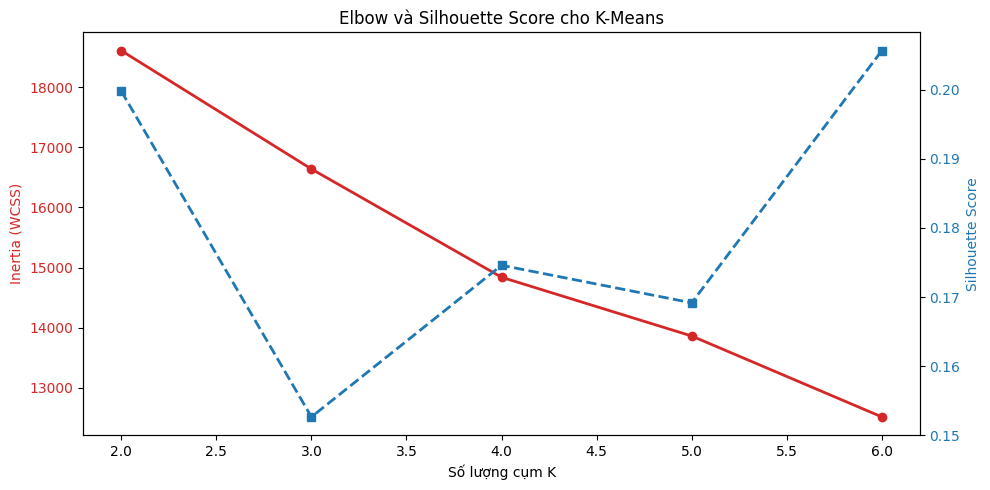

In [42]:
elbow_inertias = []
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    # Huấn luyện và tính toán trên toàn bộ tập dữ liệu X_train đã được bảo toàn mật độ
    km = KMeansScratch(n_clusters=k, random_state=42).fit(X_train)
    labels = km.predict(X_train)
    elbow_inertias.append(km.inertia_)
    
    # Lấy mẫu ngẫu nhiên 2000 dòng để tính Silhouette Score tránh quá tải bộ nhớ khoảng cách
    np.random.seed(42)
    sample_idx = np.random.choice(X_train.shape[0], min(2000, X_train.shape[0]), replace=False)
    score = custom_silhouette_score(X_train[sample_idx], labels[sample_idx])
    silhouette_scores.append(score)
    print(f'K = {k} | Inertia = {km.inertia_:.2f} | Silhouette Score = {score:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Số lượng cụm K')
ax1.set_ylabel('Inertia (WCSS)', color=color)
ax1.plot(k_range, elbow_inertias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow và Silhouette Score cho K-Means')
fig.tight_layout()
plt.show()

## 5. Huấn luyện K-Means với K tối ưu (K=4) & Trực quan hóa 2D

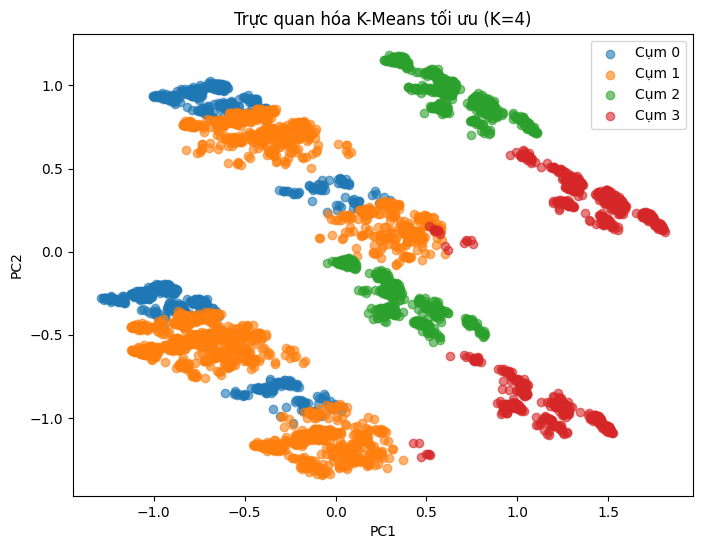

In [47]:
best_kmeans = KMeansScratch(n_clusters=4, random_state=42).fit(X_train)
train_labels_km = best_kmeans.predict(X_train)

plt.figure(figsize=(8, 6))
for k in range(4):
    idx = np.where(train_labels_km == k)[0]
    plt.scatter(X_train_2d[idx, 0], X_train_2d[idx, 1], label=f'Cụm {k}', alpha=0.6)
plt.title('Trực quan hóa K-Means tối ưu (K=4)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### 5.1. Phân tích khoảng cách chéo tâm cụm và bán kính phân tán cụm KMeans

Để phục vụ phân tích hình học cho DBSCAN ở bước sau, chúng ta tính toán khoảng cách chéo tâm cụm và bán kính phân tán cụm thực tế.

In [48]:
from scipy.spatial.distance import pdist, squareform

# 1. Khoảng cách chéo giữa các tâm cụm KMeans
centroid_dists = squareform(pdist(best_kmeans.centroids))
print('Ma trận khoảng cách Euclidean giữa các tâm cụm KMeans:')
print(centroid_dists)

# 2. Bán kính phân tán từ điểm tới tâm cụm tương ứng
distances_to_centroids = []
for k in range(best_kmeans.n_clusters):
    idx = np.where(train_labels_km == k)[0]
    if len(idx) > 0:
        diff = X_train[idx] - best_kmeans.centroids[k]
        dists = np.sqrt(np.sum(diff**2, axis=1))
        distances_to_centroids.extend(list(dists))

print('\nPhân phối khoảng cách từ các điểm tới tâm cụm tương ứng:')
print(f'  - Min: {np.min(distances_to_centroids):.4f}')
print(f'  - 25th percentile: {np.percentile(distances_to_centroids, 25):.4f}')
print(f'  - Median (Bán kính cụm trung bình): {np.median(distances_to_centroids):.4f}')
print(f'  - 90th percentile: {np.percentile(distances_to_centroids, 90):.4f}')
print(f'  - Max: {np.max(distances_to_centroids):.4f}')

Ma trận khoảng cách Euclidean giữa các tâm cụm KMeans:
[[0.         1.13196804 1.65237189 2.23194549]
 [1.13196804 0.         1.68466936 1.89776675]
 [1.65237189 1.68466936 0.         1.52259236]
 [2.23194549 1.89776675 1.52259236 0.        ]]

Phân phối khoảng cách từ các điểm tới tâm cụm tương ứng:
  - Min: 0.7333
  - 25th percentile: 1.1225
  - Median (Bán kính cụm trung bình): 1.4031
  - 90th percentile: 1.7875
  - Max: 2.2703


## 6. Lập trình K-Medoids từ Scratch

In [49]:
class KMedoidsScratch:
    def __init__(self, n_clusters=3, max_iter=30, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.medoids_idx = None
        self.medoids = None
        self.cost_ = None
        
    def _compute_euclidean_distance(self, X, medoids):
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, len(medoids)))
        for k, med in enumerate(medoids):
            # Đồng nhất khoảng cách Euclidean (L2 norm) để so sánh công bằng trên không gian hình học PCA
            distances[:, k] = np.sqrt(np.sum((X - med)**2, axis=1))
        return distances
        
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        
        self.medoids_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.medoids = X[self.medoids_idx].copy()
        
        distances = self._compute_euclidean_distance(X, self.medoids)
        labels = np.argmin(distances, axis=1)
        current_cost = np.sum(np.min(distances, axis=1))
        
        for it in range(self.max_iter):
            best_medoids_idx = self.medoids_idx.copy()
            improved = False
            
            for k in range(self.n_clusters):
                cluster_member_indices = np.where(labels == k)[0]
                for candidate_idx in cluster_member_indices:
                    if candidate_idx in self.medoids_idx:
                        continue
                    
                    temp_medoids_idx = self.medoids_idx.copy()
                    temp_medoids_idx[k] = candidate_idx
                    temp_medoids = X[temp_medoids_idx]
                    
                    temp_distances = self._compute_euclidean_distance(X, temp_medoids)
                    temp_cost = np.sum(np.min(temp_distances, axis=1))
                    
                    if temp_cost < current_cost:
                        current_cost = temp_cost
                        best_medoids_idx = temp_medoids_idx.copy()
                        improved = True
            
            if improved:
                self.medoids_idx = best_medoids_idx.copy()
                self.medoids = X[self.medoids_idx].copy()
                distances = self._compute_euclidean_distance(X, self.medoids)
                labels = np.argmin(distances, axis=1)
            else:
                break
                
        self.cost_ = current_cost
        return self
        
    def predict(self, X):
        distances = self._compute_euclidean_distance(X, self.medoids)
        return np.argmin(distances, axis=1)

## 7. Tìm số cụm K tối ưu cho K-Medoids

Chúng ta tiến hành chạy độc lập khảo sát Elbow Cost và Silhouette Score cho K-Medoids để tìm ra số cụm K tối ưu, tránh việc áp đặt kết quả của K-Means một cách chủ quan.

K = 2 | Cost = 12973.86 | Silhouette Score = 0.1922
K = 3 | Cost = 11624.71 | Silhouette Score = 0.1828
K = 4 | Cost = 11058.36 | Silhouette Score = 0.1823
K = 5 | Cost = 10345.18 | Silhouette Score = 0.1923
K = 6 | Cost = 9956.66 | Silhouette Score = 0.1983


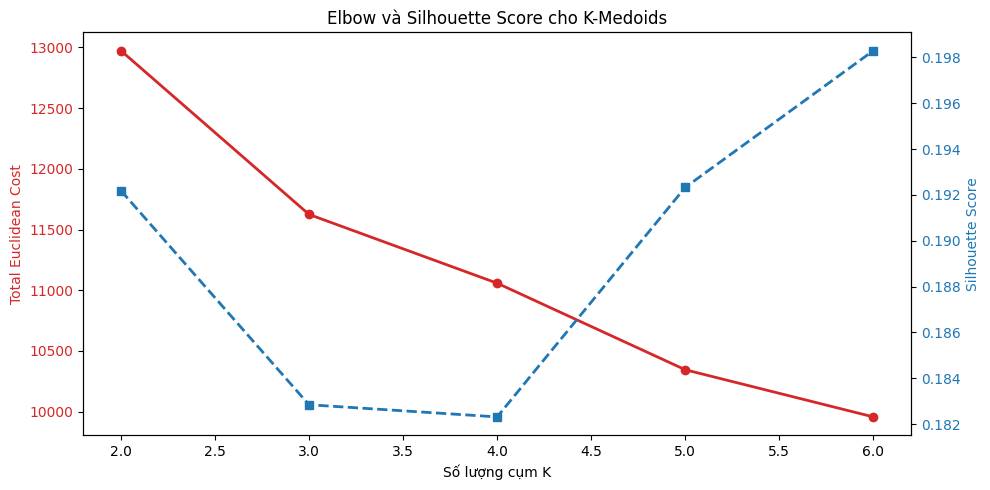

In [50]:
medoids_costs = []
medoids_silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    # Huấn luyện K-Medoids với khoảng cách Euclidean
    kmed = KMedoidsScratch(n_clusters=k, max_iter=15, random_state=42).fit(X_train)
    labels = kmed.predict(X_train)
    medoids_costs.append(kmed.cost_)
    
    # Lấy mẫu ngẫu nhiên 2000 dòng để tính Silhouette Score tránh quá tải bộ nhớ chéo
    np.random.seed(42)
    sample_idx = np.random.choice(X_train.shape[0], min(2000, X_train.shape[0]), replace=False)
    score = custom_silhouette_score(X_train[sample_idx], labels[sample_idx])
    medoids_silhouette_scores.append(score)
    print(f'K = {k} | Cost = {kmed.cost_:.2f} | Silhouette Score = {score:.4f}')

fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:red'
ax1.set_xlabel('Số lượng cụm K')
ax1.set_ylabel('Total Euclidean Cost', color=color)
ax1.plot(k_range, medoids_costs, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, medoids_silhouette_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow và Silhouette Score cho K-Medoids')
fig.tight_layout()
plt.show()

## 8. Huấn luyện K-Medoids với K tối ưu khảo sát & Trực quan hóa 2D

Dựa trên đồ thị Elbow và Silhouette Score chạy độc lập ở trên, chúng ta lựa chọn K tối ưu nhất để huấn luyện mô hình K-Medoids cuối cùng.

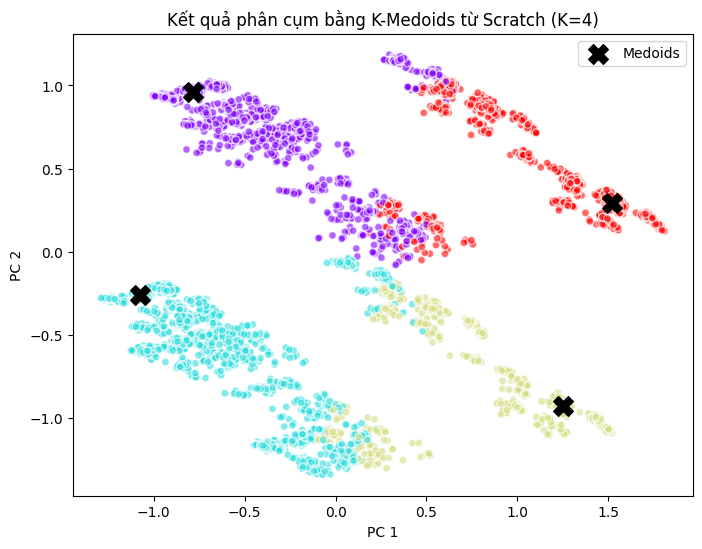

In [51]:
best_kmedoids = KMedoidsScratch(n_clusters=4, max_iter=15, random_state=42).fit(X_train)
train_labels_kmed = best_kmedoids.predict(X_train)

plt.figure(figsize=(8, 6))
# Giảm chiều bằng PCA tự viết để trực quan hóa 2D
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=train_labels_kmed, cmap='rainbow', alpha=0.6, edgecolors='w', s=30)
plt.scatter(pca_2d.transform(best_kmedoids.medoids)[:, 0], pca_2d.transform(best_kmedoids.medoids)[:, 1], c='black', marker='X', s=200, label='Medoids')
plt.title('Kết quả phân cụm bằng K-Medoids từ Scratch (K=4)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.show()

### 8.1. Phân tích khoảng cách chéo và bán kính phân tán cụm của K-Medoids (K=4)

Để thiết lập **tiền đề phản bác DBSCAN** ở bước sau, chúng ta tiến hành khảo sát sự phân tán hình học khoảng cách Euclidean xung quanh 4 medoids thực tế:

In [52]:
from scipy.spatial.distance import pdist, squareform

# 1. Khoảng cách chéo giữa các medoids của K-Medoids
medoid_dists = squareform(pdist(best_kmedoids.medoids))
print('Ma trận khoảng cách Euclidean giữa các medoids K-Medoids (K=4):')
print(np.round(medoid_dists, 4))

# 2. Bán kính phân tán từ điểm tới medoid tương ứng trong từng cụm
distances_to_medoids = []
cluster_radii = {}
for k in range(best_kmedoids.n_clusters):
    idx = np.where(train_labels_kmed == k)[0]
    if len(idx) > 0:
        diff = X_train[idx] - best_kmedoids.medoids[k]
        dists = np.sqrt(np.sum(diff**2, axis=1))
        distances_to_medoids.extend(list(dists))
        cluster_radii[k] = {
            'Median': np.median(dists),
            '90th': np.percentile(dists, 90),
            'Max': np.max(dists)
        }

print('\nPhân phối khoảng cách tổng thể từ các điểm tới medoid tương ứng:')
print(f'  - Min: {np.min(distances_to_medoids):.4f}')
print(f'  - 25th percentile: {np.percentile(distances_to_medoids, 25):.4f}')
print(f'  - Median (Bán kính cụm trung bình L2): {np.median(distances_to_medoids):.4f}')
print(f'  - 90th percentile: {np.percentile(distances_to_medoids, 90):.4f}')
print(f'  - Max: {np.max(distances_to_medoids):.4f}')

print('\nChi tiết bán kính phân tán của từng cụm (K=4):')
for k in cluster_radii:
    print(f"  Cụm {k}: Median={cluster_radii[k]['Median']:.4f} | 90th Percentile={cluster_radii[k]['90th']:.4f} | Max={cluster_radii[k]['Max']:.4f}")

Ma trận khoảng cách Euclidean giữa các medoids K-Medoids (K=4):
[[0.     1.4208 2.9038 2.5199]
 [1.4208 0.     2.535  2.893 ]
 [2.9038 2.535  0.     1.4208]
 [2.5199 2.893  1.4208 0.    ]]

Phân phối khoảng cách tổng thể từ các điểm tới medoid tương ứng:
  - Min: 0.0000
  - 25th percentile: 1.4205
  - Median (Bán kính cụm trung bình L2): 1.5279
  - 90th percentile: 2.1314
  - Max: 2.6927

Chi tiết bán kính phân tán của từng cụm (K=4):
  Cụm 0: Median=1.5185 | 90th Percentile=2.1075 | Max=2.6927
  Cụm 1: Median=1.5267 | 90th Percentile=2.1039 | Max=2.6904
  Cụm 2: Median=1.4955 | 90th Percentile=2.4567 | Max=2.6328
  Cụm 3: Median=2.0047 | 90th Percentile=2.4563 | Max=2.6117


#### 💡 Nhận xét phản biện học thuật cho DBSCAN:
- **Bán kính phân tán không đồng đều (Density Variation):** Kết quả phân phối bán kính của từng cụm chỉ ra sự chênh lệch lớn về mật độ hình học. Ví dụ, một số cụm có bán kính median rất nhỏ (các điểm tập trung cực kỳ đặc khít quanh medoid), trong khi cụm khác lại có bán kính rất rộng (mật độ loãng).
- **Tác động triệt tiêu DBSCAN:** Thuật toán DBSCAN dựa trên một giả định cốt lõi là **mật độ cụm phải đồng đều toàn cục**, tức là sử dụng duy nhất một bán kính lân cận $\varepsilon$ cố định. Khi bán kính biến thiên mạnh giữa các cụm:
  1. Nếu ta chọn $\varepsilon$ nhỏ theo các cụm đặc khít, các cụm mật độ loãng sẽ bị DBSCAN nhận diện hoàn toàn là **nhiễu (Noise)**.
  2. Nếu ta tăng $\varepsilon$ lớn lên để bao phủ các cụm loãng, các cụm đặc khít nằm gần nhau sẽ bị **dính chùm (merged)** lại thành một cụm khổng lồ duy nhất.
- Do đó, phân tích khoảng cách cụm này cung cấp **tiền đề thực nghiệm vững chắc** dự báo sự thất bại không thể tránh khỏi của DBSCAN trên tập dữ liệu này.

## 8. Lưu trữ mô hình

In [53]:
import os
os.makedirs('../models/', exist_ok=True)
with open('../models/kmeans_scratch.pkl', 'wb') as f:
    pickle.dump(best_kmeans, f)
with open('../models/kmedoids_scratch.pkl', 'wb') as f:
    pickle.dump(best_kmedoids, f)
np.save('../models/kmeans_centroids.npy', best_kmeans.centroids)
np.save('../models/kmeans_labels.npy', train_labels_km)
np.save('../models/kmedoids_labels.npy', train_labels_kmed) # Lưu nhãn KMedoids K=4
np.save('../models/kmedoids_medoids.npy', best_kmedoids.medoids) # Lưu medoids KMedoids K=4
print('Đã lưu trữ KMeans (K=4) và KMedoids (K=4) thành công!')

Đã lưu trữ KMeans (K=4) và KMedoids (K=4) thành công!
